In [ ]:
# 1) Loading the Taxis Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [ ]:
# 2) Handling Missing Values

# Check missing values
print(df.isnull().sum())

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill missing values in numerical columns using median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing values in categorical columns using mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove rows with missing values
df.dropna(subset=['pickup', 'dropoff'], inplace=True)

# Verify missing values
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


/tmp/ipykernel_1656/2649958923.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1656/2649958923.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
# Convert pickup column to datetime

df['pickup'] = pd.to_datetime(df['pickup'])

# Check datatypes
print(df.dtypes)

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object


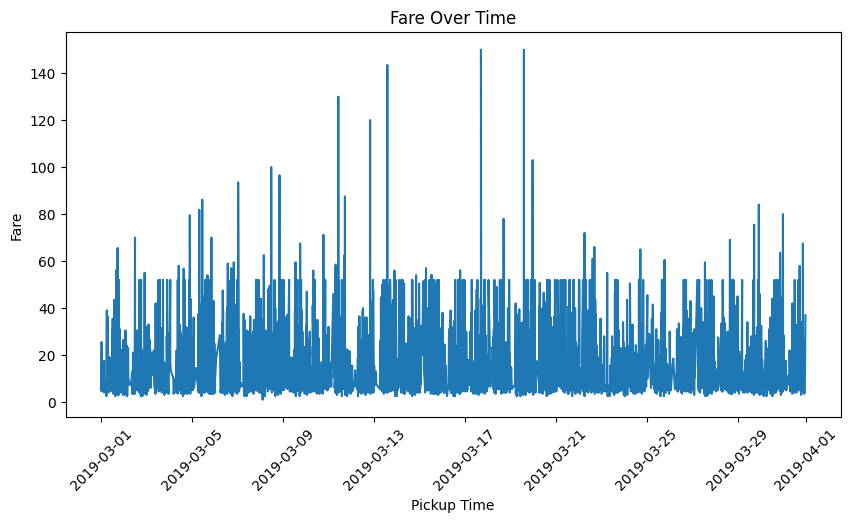

In [ ]:
# Line Chart - Fare over Time

df_sorted = df.sort_values('pickup')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['pickup'], df_sorted['fare'])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)
plt.show()

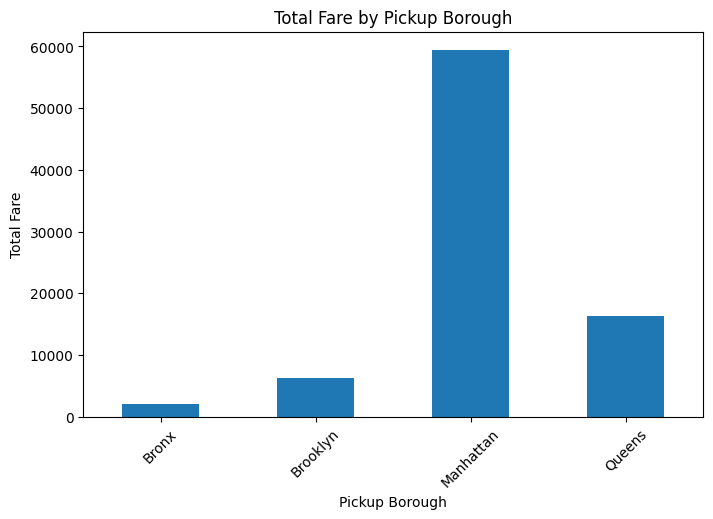

In [ ]:
# Bar Chart - Total Fare by Pickup Borough

borough_fare = df.groupby('pickup_borough')['fare'].sum()

borough_fare.plot(kind='bar', figsize=(8,5))

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.xticks(rotation=45)
plt.show()

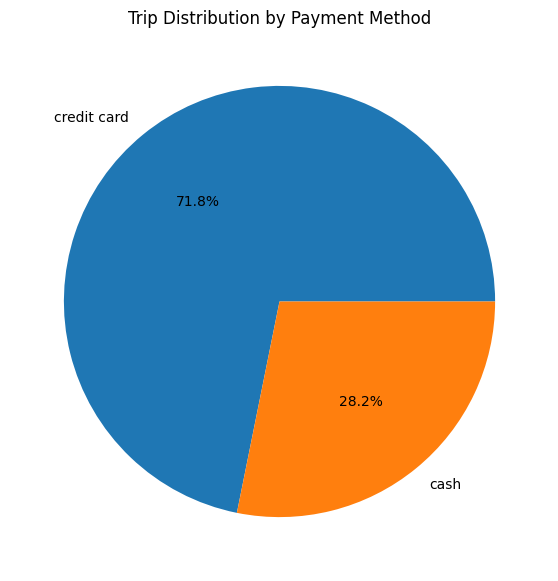

In [ ]:
# Pie Chart - Distribution of Payment Methods

payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Trip Distribution by Payment Method")

plt.show()

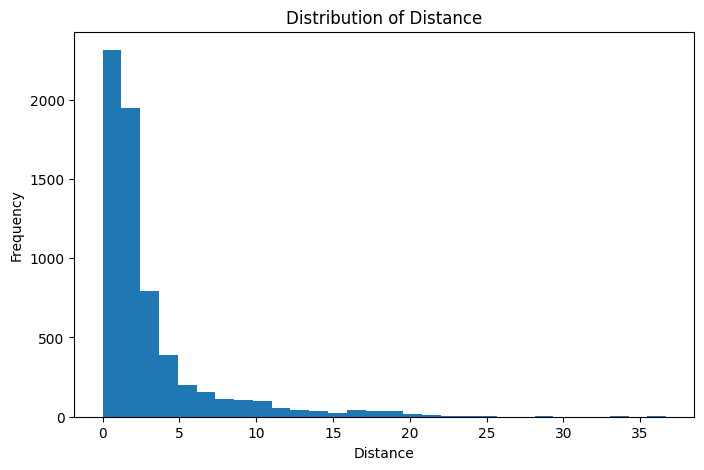

In [ ]:
# Histogram - Distribution of Distance

plt.figure(figsize=(8,5))

plt.hist(df['distance'], bins=30)

plt.title("Distribution of Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

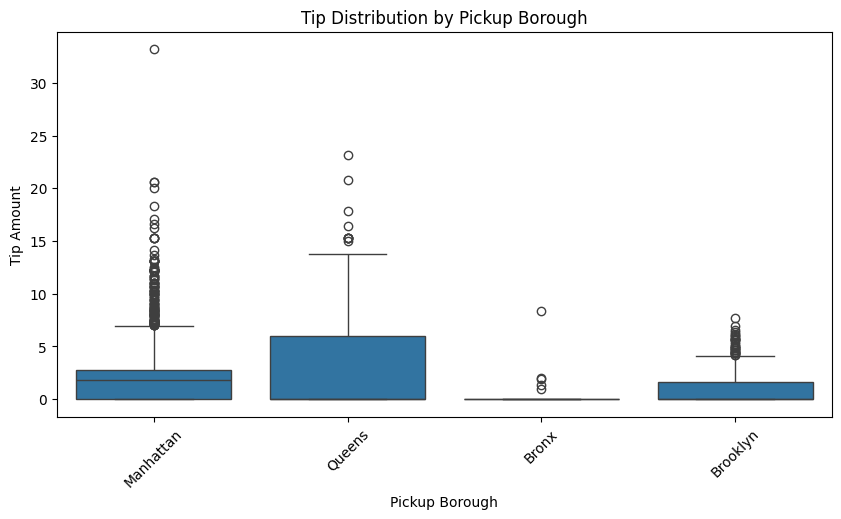

In [ ]:
# Box Plot - Tip Amount by Pickup Borough

plt.figure(figsize=(10,5))

sns.boxplot(
    x='pickup_borough',
    y='tip',
    data=df
)

plt.title("Tip Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")

plt.xticks(rotation=45)
plt.show()

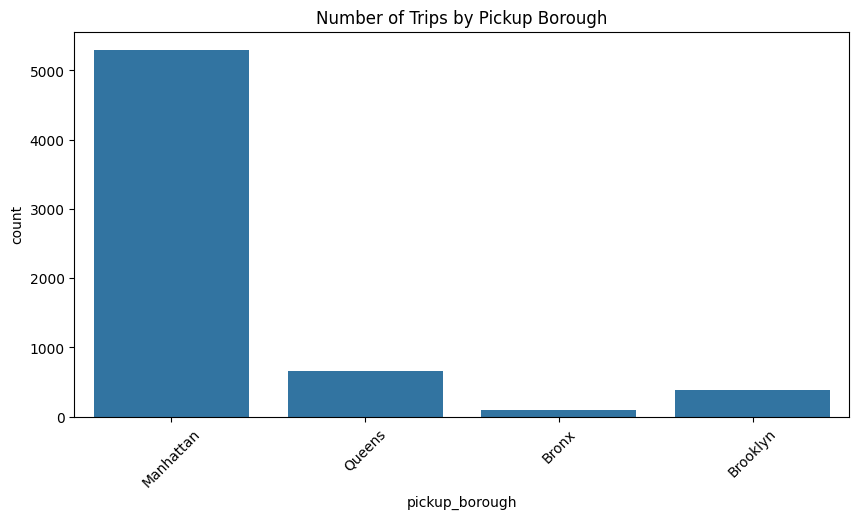

In [ ]:
# Count Plot - Number of Trips in Each Pickup Borough

plt.figure(figsize=(10,5))

sns.countplot(
    x='pickup_borough',
    data=df
)

plt.title("Number of Trips by Pickup Borough")

plt.xticks(rotation=45)
plt.show()

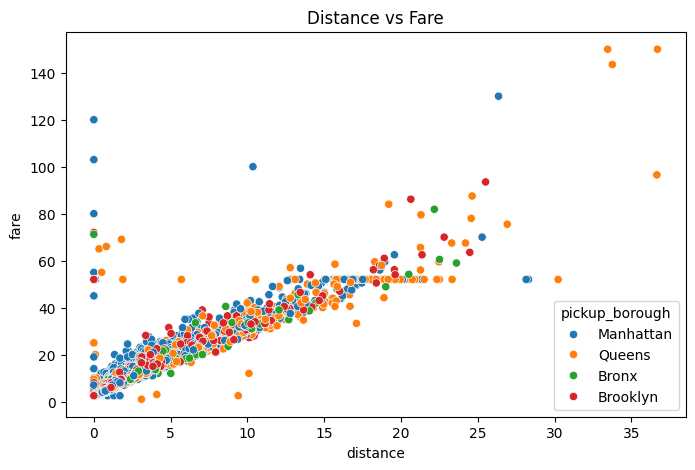

In [ ]:
# Scatter Plot - Distance vs Fare

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='distance',
    y='fare',
    hue='pickup_borough',
    data=df
)

plt.title("Distance vs Fare")

plt.show()

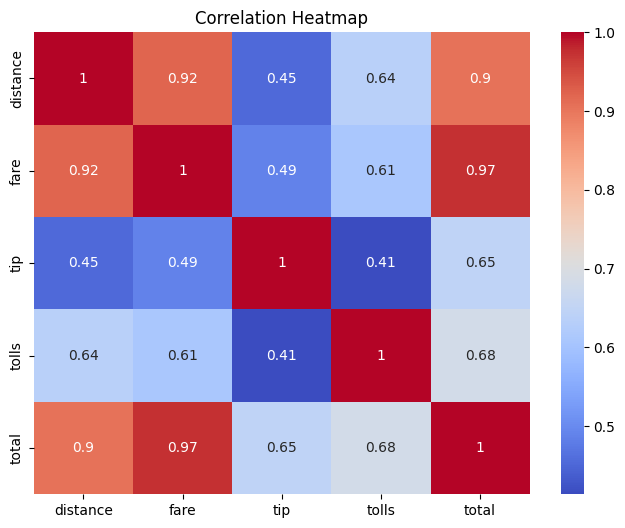

In [ ]:
# Heatmap - Correlation Between Numerical Variables

corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

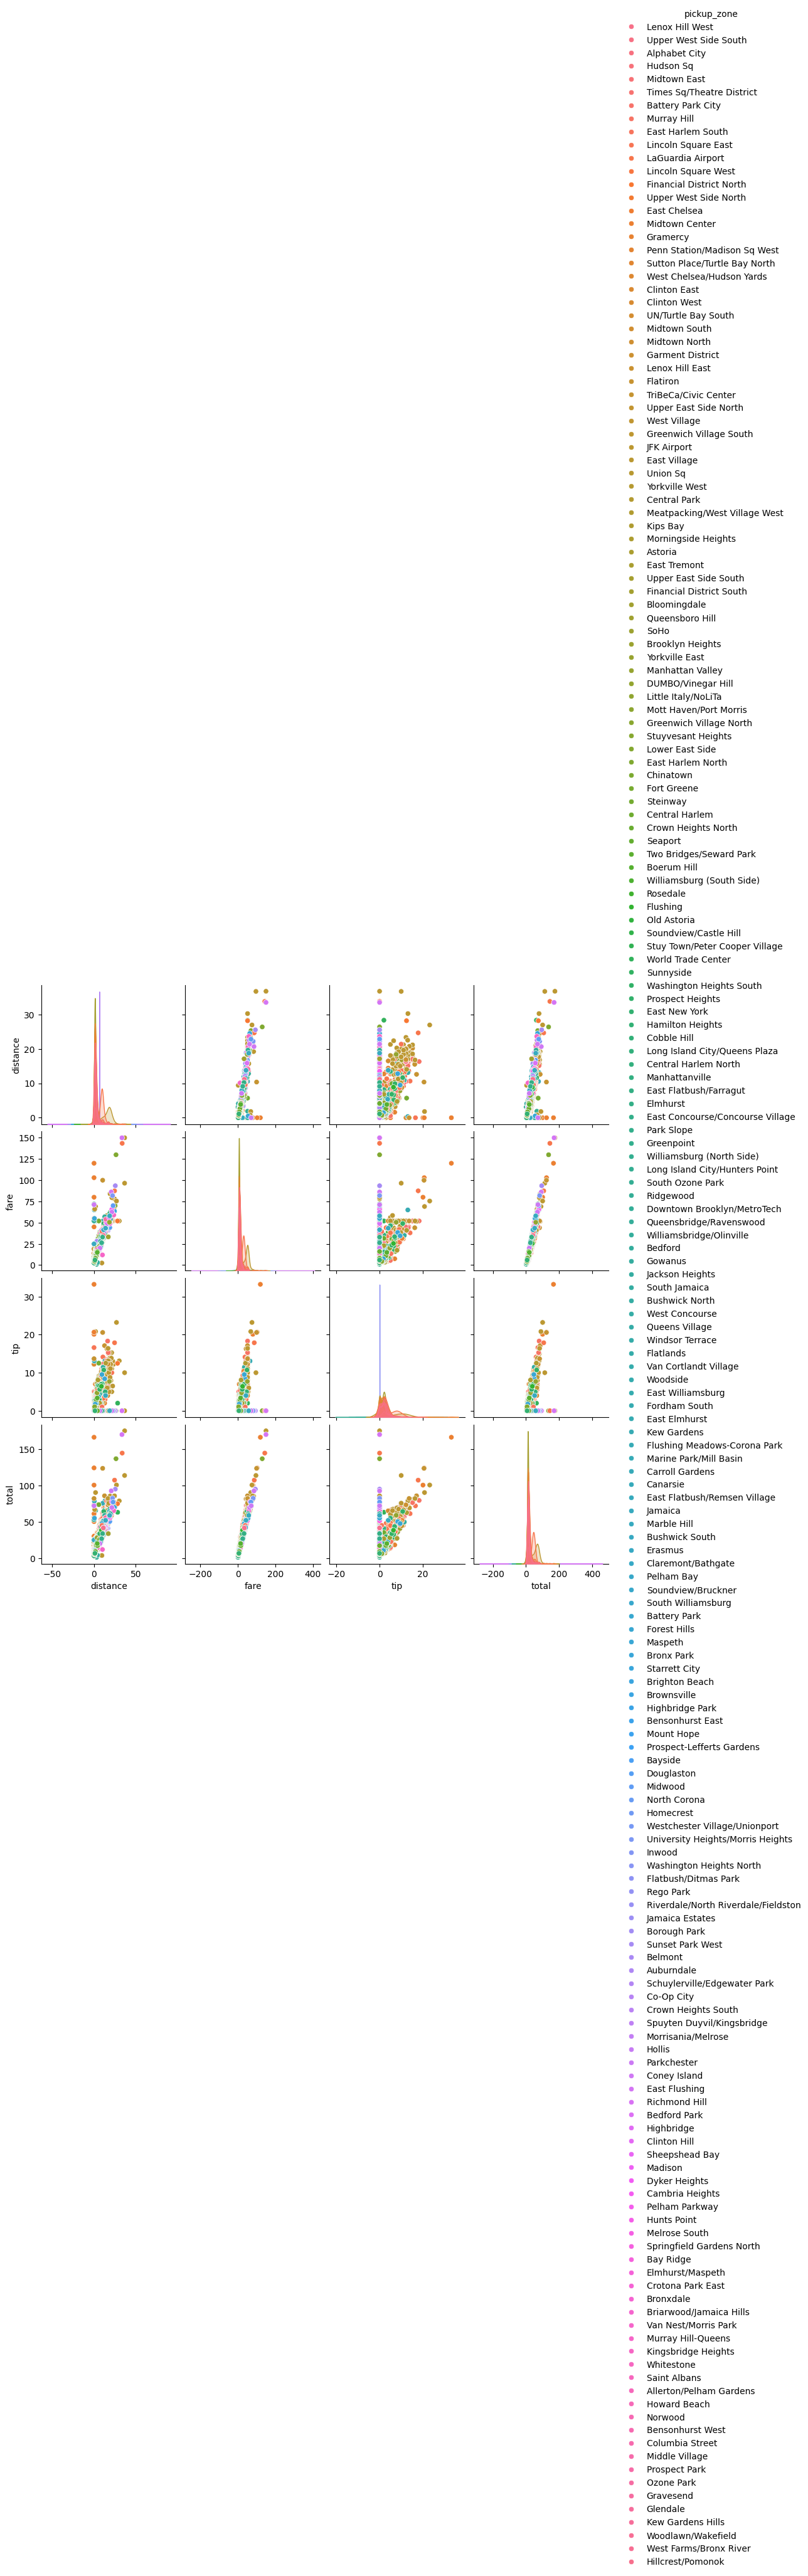

In [ ]:
# Pair Plot - Pairwise Relationships

sns.pairplot(
    df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
    hue='pickup_zone'
)

plt.show()

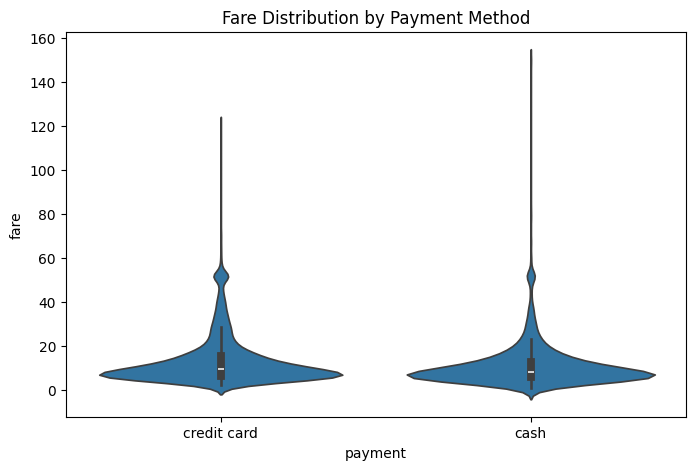

In [ ]:
# Violin Plot - Fare Distribution by Payment Method

plt.figure(figsize=(8,5))

sns.violinplot(
    x='payment',
    y='fare',
    data=df
)

plt.title("Fare Distribution by Payment Method")

plt.show()